In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import petals

(250, 5) (250,)


In [21]:
def train_eval_tree(N):
    X_train, y_train = petals.training_data(N=N, seed=37)
    X_test, y_test = petals.training_data(N=1000, seed=42)
    
    model = HistGradientBoostingRegressor(
        max_iter=1000,
        learning_rate=0.03,
        max_leaf_nodes=31,
        l2_regularization=0.0,
        random_state=37
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)
    print("R2:", r2_score(y_test, y_pred))
    print(f"miscalibration: {y_pred.mean() - y_test.mean():0.3f}")
    
    accuracy = np.mean(y_test == np.rint(y_pred))
    
    plt.title("Predicted vs. Actual")
    plt.ylim(0, 20)
    plt.xlim(0, 20)
    plt.scatter(y_test, y_pred, alpha=10 / len(y_test))
    plt.plot([0, 20], [0, 20], linestyle="--", color="lightgray")
    plt.legend([f'Accuracy: {accuracy*100:.2f}%'])

    return model


MAE: 2.78820353269959
RMSE: 3.4085793452572086
R2: 0.005185629894773114
miscalibration: 0.374


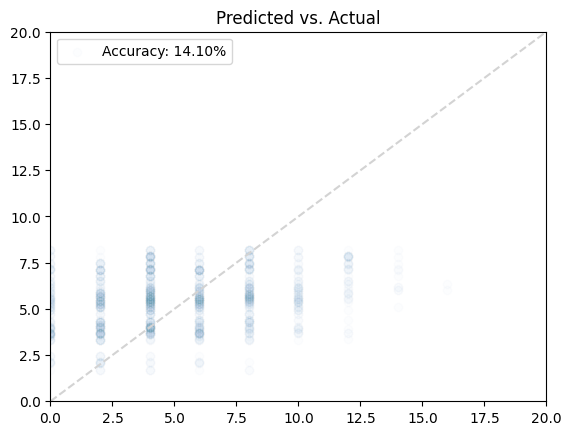

In [31]:
train_eval_tree(50);

MAE: 0.28390271388177085
RMSE: 0.35839345528888633
R2: 0.9890019579803994
miscalibration: 0.004


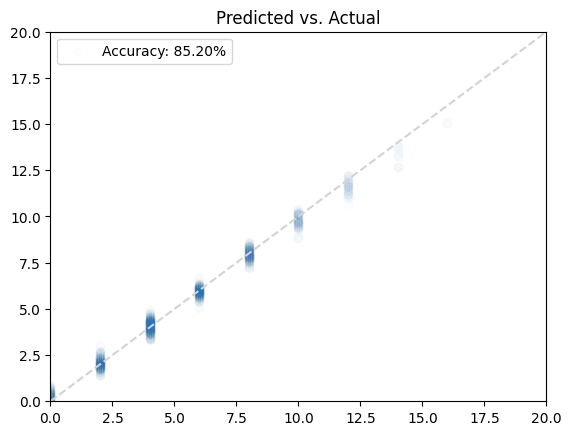

In [27]:
train_eval_tree(150);

MAE: 0.3987464703453128
RMSE: 0.5299215752875518
R2: 0.9759553512264054
miscalibration: 0.024


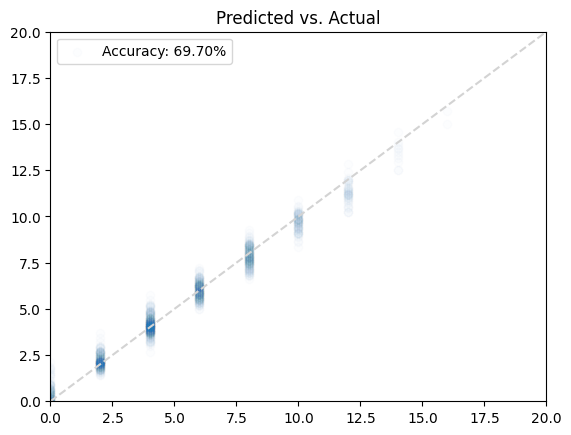

In [32]:
train_eval_tree(300);

MAE: 0.2202632664972707
RMSE: 0.29805428724442967
R2: 0.9923934805461725
miscalibration: -0.008


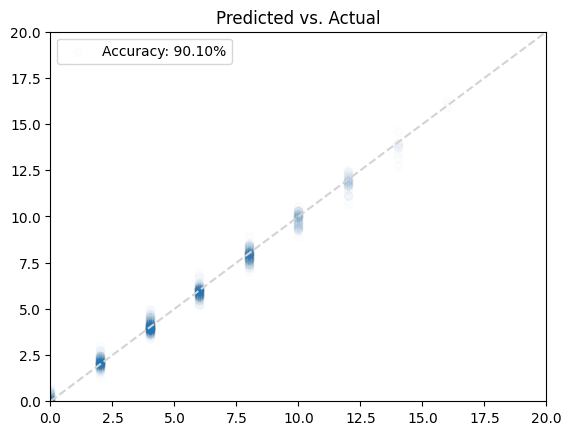

In [33]:
train_eval_tree(1000);

MAE: 0.1125321025578693
RMSE: 0.16252831261587583
R2: 0.9977382047534165
miscalibration: 0.003


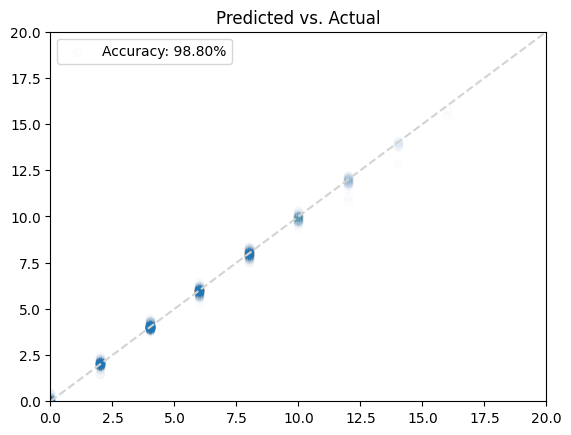

In [64]:
train_eval_tree(2_000);

MAE: 0.05333138657719897
RMSE: 0.07496882637325307
R2: 0.9995187656068663
miscalibration: -0.002


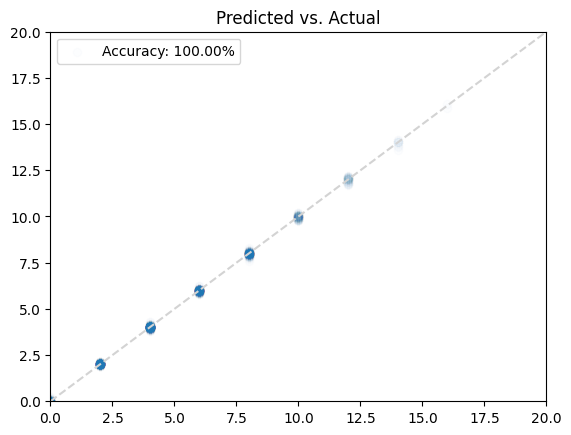

In [65]:
train_eval_tree(5_000);

In [34]:
from dataclasses import dataclass, asdict


@dataclass
class Result:
    N: int
    mae: float
    rmse: float
    r2: float
    miscalibration: float
    accuracy: float


def train_tree(N):
    X_train, y_train = petals.training_data(N=N, seed=37)
    X_test, y_test = petals.training_data(N=1000, seed=42)

    model = HistGradientBoostingRegressor(
        max_iter=1000,
        learning_rate=0.03,
        max_leaf_nodes=31,
        l2_regularization=0.0,
        random_state=37
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    return Result(
        N=N,
        mae=mean_absolute_error(y_test, y_pred),
        rmse=mean_squared_error(y_test, y_pred) ** 0.5,
        r2=r2_score(y_test, y_pred),
        miscalibration=y_pred.mean() - y_test.mean(),
        accuracy=np.mean(y_test == np.rint(y_pred)),
    )


results = [
    asdict(train_tree(N))
    for N in range(100, 1001, 100)
]

df = pd.DataFrame(results)

df

,N,mae,rmse,r2,miscalibration,accuracy
0,100,2.185928,2.733403,0.360262,0.376845,0.131
1,200,0.345853,0.451052,0.982580,0.024519,0.747
2,300,0.398746,0.529922,0.975955,0.023503,0.697
3,400,0.293717,0.391441,0.986880,-0.032798,0.836
4,500,0.275818,0.359157,0.988955,0.001754,0.833
5,600,0.256892,0.341025,0.990042,-0.001753,0.864
6,700,0.249175,0.340261,0.990087,-0.013660,0.876
7,800,0.244479,0.336093,0.990328,-0.001549,0.881
8,900,0.247320,0.346718,0.989707,-0.015081,0.873
9,1000,0.220263,0.298054,0.992393,-0.007809,0.901


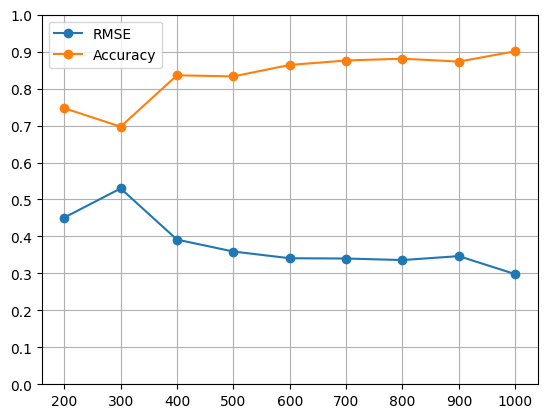

In [63]:
df2 = df[ df["N"] > 100 ]
plt.plot(df2["N"], df2["rmse"], "o-", label="RMSE")
plt.plot(df2["N"], df2["accuracy"], "o-", label="Accuracy")
plt.ylim(0, 1)
plt.yticks(np.linspace(0, 1.0, num=11))
plt.grid()
plt.legend()